# TabPFN-Wide attention smoke test

First real attention run. Check the query invariance control before interpreting rankings.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from stablewide.notebook_utils import find_project_root, run_experiment, read_outputs, core_subsample_table
ROOT = find_project_root(ROOT)
print(ROOT)

C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL


In [2]:
try:
    import tabpfnwide
    print("tabpfnwide available")
except Exception as e:
    raise RuntimeError("Install tabpfnwide before this notebook: pip install tabpfnwide") from e

tabpfnwide available


C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\.venv\Scripts\python.exe C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\run_experiment.py --synthetic --quick --methods anova,rf,l1,l2,attention --out C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\outputs\02_attention_smoke
[03:19:46] outer 0: raw n=440, p=500, pool=352, test=88, split_seed=0
[03:19:46] outer 0: seed stability -> rf
[03:19:47]     rf: 3/3 runs (1s)
[03:19:47] outer 0: seed stability -> attention
[03:21:54]     attention: 3/3 runs (127s)
[03:21:54] outer 0: attention readout-composition control (5 context sets)
[03:24:31]     attention: 5/5 runs (157s)
[03:24:31] outer 0: subsample n=100
[03:24:31]     anova: 5/5 runs (0s)
[03:24:33]     rf: 5/5 runs (2s)
[03:24:33]     l1: 5/5 runs (0s)
[03:24:33]     l2: 5/5 runs (0s)
[03:25:46]     attention: 5/5 runs (73s)
[03:25:46] outer 0: subsample n=50
[03:25:46]     anova: 5/5 runs (0s)
[03:25:48]     rf: 5/5 runs (2s)
[03:25:49]     l1: 5/5 runs (0s)
[03:25:49]     l2: 5/5

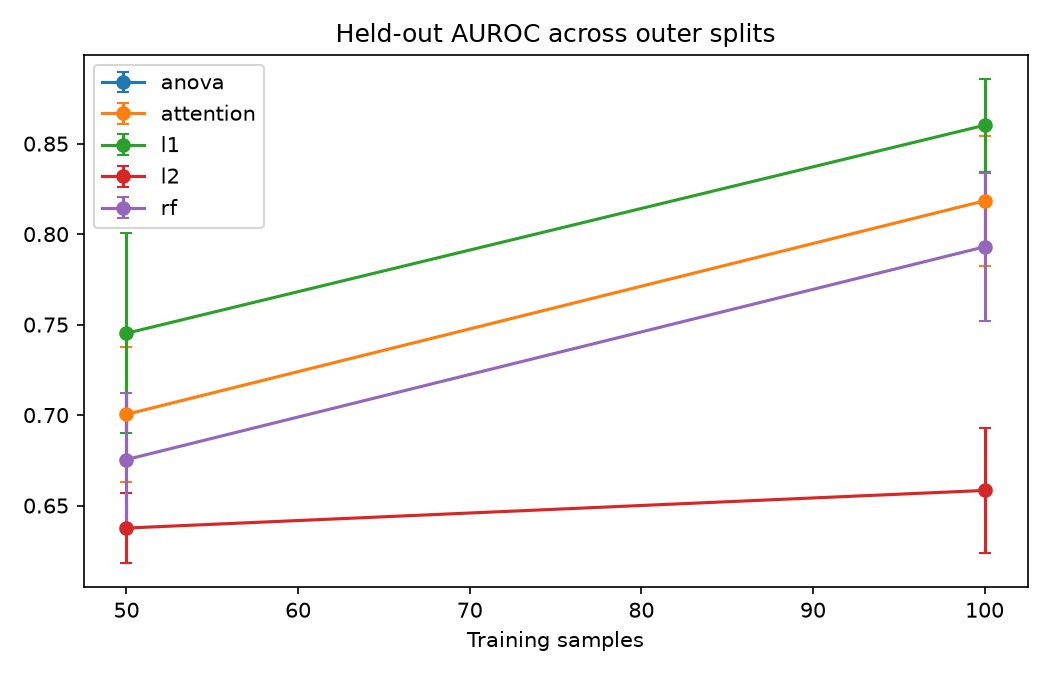


[aggregate_fixed_k_pairwise.csv]


,reference,baseline,n_train,k,n_outer_rows,delta_gene_jaccard_mean,delta_gene_jaccard_ci_low,delta_gene_jaccard_ci_high,delta_gene_jaccard_n,delta_module_jaccard_mean,...,baseline_gene_jaccard_ci_high,baseline_gene_jaccard_n,reference_auroc_mean,reference_auroc_ci_low,reference_auroc_ci_high,reference_auroc_n,baseline_auroc_mean,baseline_auroc_ci_low,baseline_auroc_ci_high,baseline_auroc_n
0,attention,l2,50,10,2,0.017699,-0.006433,0.041830,2,0.106765,...,0.132224,2,0.700415,0.663081,0.737749,2,0.637565,0.618242,0.656888,2
1,attention,l2,100,10,2,0.173175,0.147852,0.198497,2,0.335347,...,0.296008,2,0.818423,0.782628,0.854219,2,0.658360,0.623606,0.693114,2
2,attention,rf,50,10,2,0.045132,0.038012,0.052253,2,0.140619,...,0.121801,2,0.700415,0.663081,0.737749,2,0.675412,0.638847,0.711976,2
3,attention,rf,100,10,2,-0.044231,-0.051282,-0.037179,2,-0.135774,...,0.545788,2,0.818423,0.782628,0.854219,2,0.792989,0.752085,0.833894,2



[aggregate_gene_stability.png]


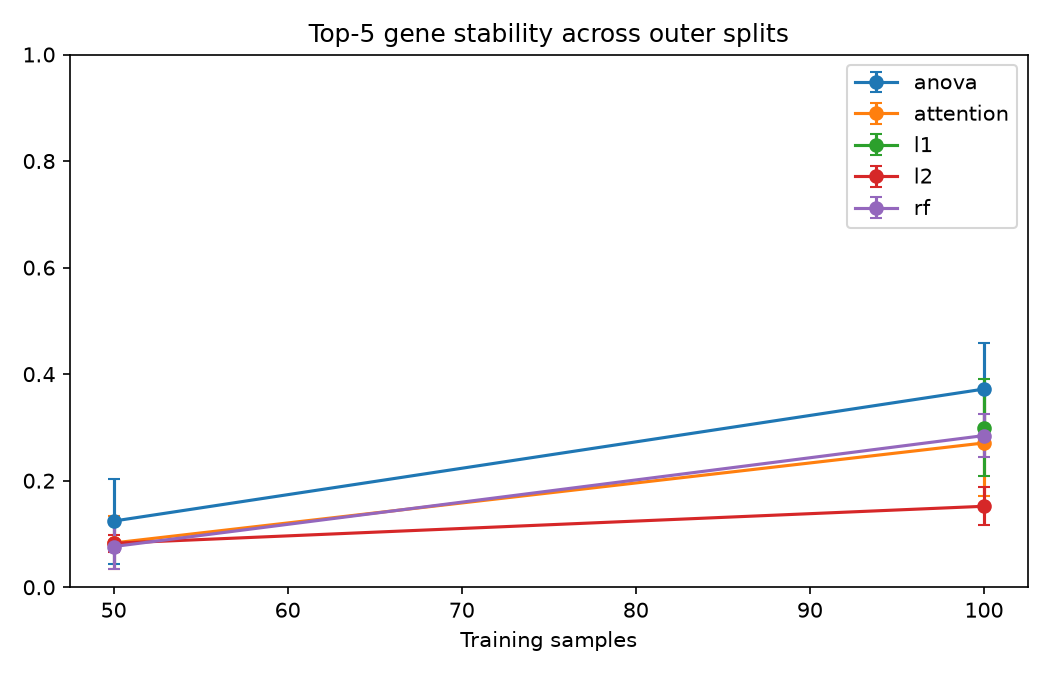


[aggregate_module_stability.png]


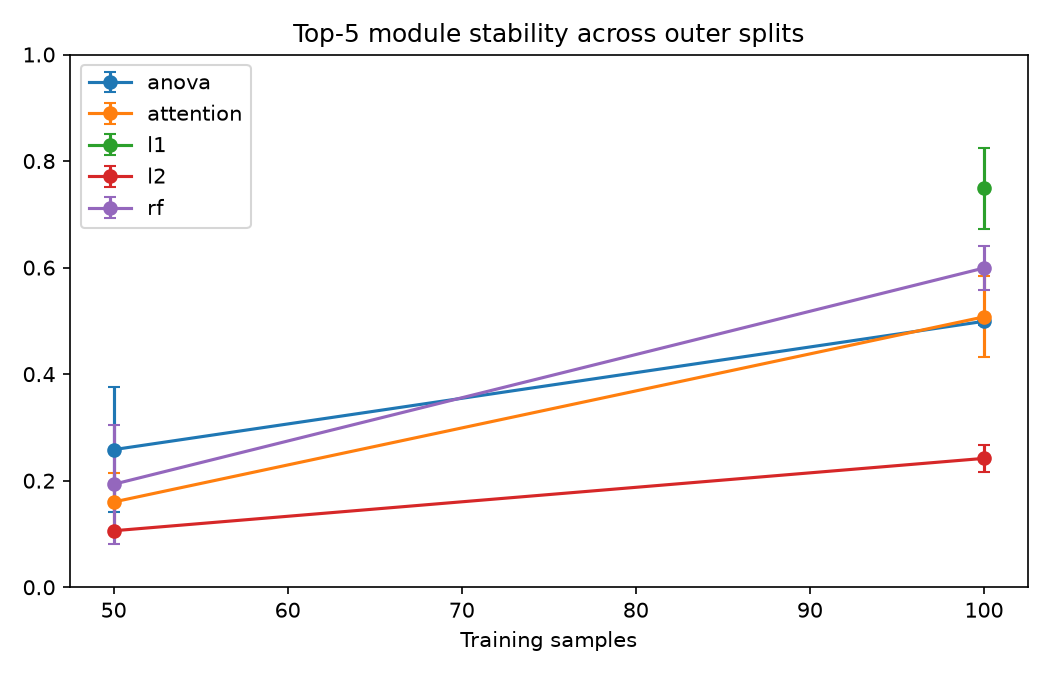


[aggregate_results.csv]


,method,experiment,n_train,k,n_outer_rows,auroc_mean_mean,auroc_mean_ci_low,auroc_mean_ci_high,auroc_mean_n,jaccard_gene_mean,...,pred_max_abs_ci_high,pred_max_abs_n,pred_jsd_mean,pred_jsd_ci_low,pred_jsd_ci_high,pred_jsd_n,pred_class_agreement_mean,pred_class_agreement_ci_low,pred_class_agreement_ci_high,pred_class_agreement_n
0,anova,subsample,50,5,2,NaN,NaN,NaN,0,0.124206,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
1,anova,subsample,50,10,2,NaN,NaN,NaN,0,0.195237,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
2,anova,subsample,50,20,2,NaN,NaN,NaN,0,0.207289,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
3,anova,subsample,50,50,2,NaN,NaN,NaN,0,0.185994,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
4,anova,subsample,100,5,2,NaN,NaN,NaN,0,0.372024,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
5,anova,subsample,100,10,2,NaN,NaN,NaN,0,0.551715,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
6,anova,subsample,100,20,2,NaN,NaN,NaN,0,0.643282,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
7,anova,subsample,100,50,2,NaN,NaN,NaN,0,0.293626,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
8,attention,query,352,5,2,0.821057,0.787946,0.854167,2,1.000000,...,0.000000,2,0.000000,0.000000,0.000000,2,1.000000,1.000000,1.000000,2
9,attention,query,352,10,2,0.821057,0.787946,0.854167,2,1.000000,...,0.000000,2,0.000000,0.000000,0.000000,2,1.000000,1.000000,1.000000,2



[aggregate_tuned_performance.csv] could not be displayed as a DataFrame.

[common_matched_budget_diagnostic_outer.csv]


,experiment,n_train,method,matched_k,auroc_mean,jaccard_gene,jaccard_module,topk_valid_fraction,method_k_maximum,method_k_maxima,note,outer_id,outer_split_seed
0,seed,352,attention,20,0.863273,1.000000,1.000000,1.0,20,"{""attention"": 20, ""rf"": 20}",NaN,0,0
1,seed,352,rf,20,0.863109,1.000000,1.000000,1.0,20,"{""attention"": 20, ""rf"": 20}",NaN,0,0
2,subsample,50,anova,3,NaN,0.040000,0.133333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
3,subsample,50,attention,3,0.663081,0.020000,0.050000,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
4,subsample,50,l1,3,0.690058,0.050000,0.140000,1.0,3,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
5,subsample,50,l2,3,0.618242,0.020000,0.053333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
6,subsample,50,rf,3,0.638847,0.060000,0.128333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
7,subsample,100,anova,17,NaN,0.547595,0.583983,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0
8,subsample,100,attention,17,0.782628,0.472672,0.447782,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0
9,subsample,100,l1,17,0.834459,0.225771,0.250083,1.0,17,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0



[fixed_k_pairwise_outer.csv]


...

,method,experiment,n_train,k,n_runs,rank_spearman_tie_aware,auroc_mean,auroc_sd,support_semantics,pred_prob_corr,...,known_median_rank,tie_boundary_fraction,support_shortfall_fraction,jaccard_index_tiebreak_diag,jaccard_random_tiebreak_diag,outer_id,outer_split_seed,query_invariance_pass,query_atol,query_rtol
0,rf,seed,352,5,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.369048,0.369048,0,0,NaN,NaN,NaN
1,rf,seed,352,10,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.674437,0.674437,0,0,NaN,NaN,NaN
2,rf,seed,352,20,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,1.000000,1.000000,0,0,NaN,NaN,NaN
3,rf,seed,352,50,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.389068,0.389068,0,0,NaN,NaN,NaN
4,attention,seed,352,5,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.619048,0.619048,0,0,NaN,NaN,NaN
5,attention,seed,352,10,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.767677,0.767677,0,0,NaN,NaN,NaN
6,attention,seed,352,20,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,1.000000,1.000000,0,0,NaN,NaN,NaN
7,attention,seed,352,50,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.563252,0.563252,0,0,NaN,NaN,NaN
8,attention,query,352,5,5,0.999884,0.854167,0.000000,none,1.000000,...,NaN,0.0,0.0,1.000000,1.000000,0,0,True,0.00001,0.0001
9,attention,query,352,10,5,0.999884,0.854167,0.000000,none,1.000000,...,NaN,0.0,0.0,1.000000,1.000000,0,0,True,0.00001,0.0001



[support_results_outer.csv]


,outer_id,outer_split_seed,experiment,n_train,method,support_semantics,support_size_mean,support_size_sd,support_size_median,support_size_min,support_size_max,support_jaccard_gene,support_jaccard_module,support_truth_precision,support_truth_recall,auroc_mean,auroc_sd
0,0,0,subsample,100,rf,positive RF importance (diagnostic support),499.2,0.748331,499.0,498,500,0.996800,1.000000,0.040064,1.00,0.752085,0.040151
1,0,0,subsample,100,l1,nonzero absolute L1 coefficient,24.2,4.261455,24.0,17,29,0.209535,0.223045,0.483818,0.57,0.834459,0.022917
2,0,0,subsample,50,rf,positive RF importance (diagnostic support),485.8,2.400000,484.0,484,490,0.944758,1.000000,0.040757,0.99,0.638847,0.031138
3,0,0,subsample,50,l1,nonzero absolute L1 coefficient,4.2,0.979796,4.0,3,6,0.052500,0.279405,0.650000,0.13,0.690058,0.074680
4,1,1009,subsample,100,rf,positive RF importance (diagnostic support),499.0,0.894427,499.0,498,500,0.996000,1.000000,0.040080,1.00,0.833894,0.020379
5,1,1009,subsample,100,l1,nonzero absolute L1 coefficient,22.6,2.727636,22.0,19,27,0.188425,0.244035,0.459917,0.51,0.885890,0.013091
6,1,1009,subsample,50,rf,positive RF importance (diagnostic support),482.8,2.925748,484.0,478,486,0.934681,1.000000,0.041427,1.00,0.711976,0.031962
7,1,1009,subsample,50,l1,nonzero absolute L1 coefficient,4.8,0.400000,5.0,4,5,0.111905,0.391429,0.750000,0.18,0.800362,0.041291



[tuned_performance_outer.csv] could not be displayed as a DataFrame.


CompletedProcess(args=['C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\.venv\\Scripts\\python.exe', 'C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\run_experiment.py', '--synthetic', '--quick', '--methods', 'anova,rf,l1,l2,attention', '--out', 'C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\outputs\\02_attention_smoke'], returncode=0, stdout='[03:19:46] outer 0: raw n=440, p=500, pool=352, test=88, split_seed=0\n[03:19:46] outer 0: seed stability -> rf\n[03:19:47]     rf: 3/3 runs (1s)\n[03:19:47] outer 0: seed stability -> attention\n[03:21:54]     attention: 3/3 runs (127s)\n[03:21:54] outer 0: attention readout-composition control (5 context sets)\n[03:24:31]     attention: 5/5 runs (157s)\n[03:24:31] outer 0: subsample n=100\n[03:24:31]     anova: 5/5 runs (0s)\n[03:24:33]     rf: 5/5 runs (2s)\n[03:24:33]     l1: 5/5 runs (0s)\n[03:24:33]     l2: 5/5 runs (0s)\n[03:25:46]     attention: 5/5 runs (73s)\n[03:25:46] outer 0: subsample n=50\n[03:25:46]     anova: 

In [3]:
OUT = ROOT / "outputs" / "02_attention_smoke"
args = [
    "--synthetic", "--quick",
    "--methods", "anova,rf,l1,l2,attention",
    "--out", str(OUT),
]
run_experiment(ROOT, args)


[aggregate_auroc.png]


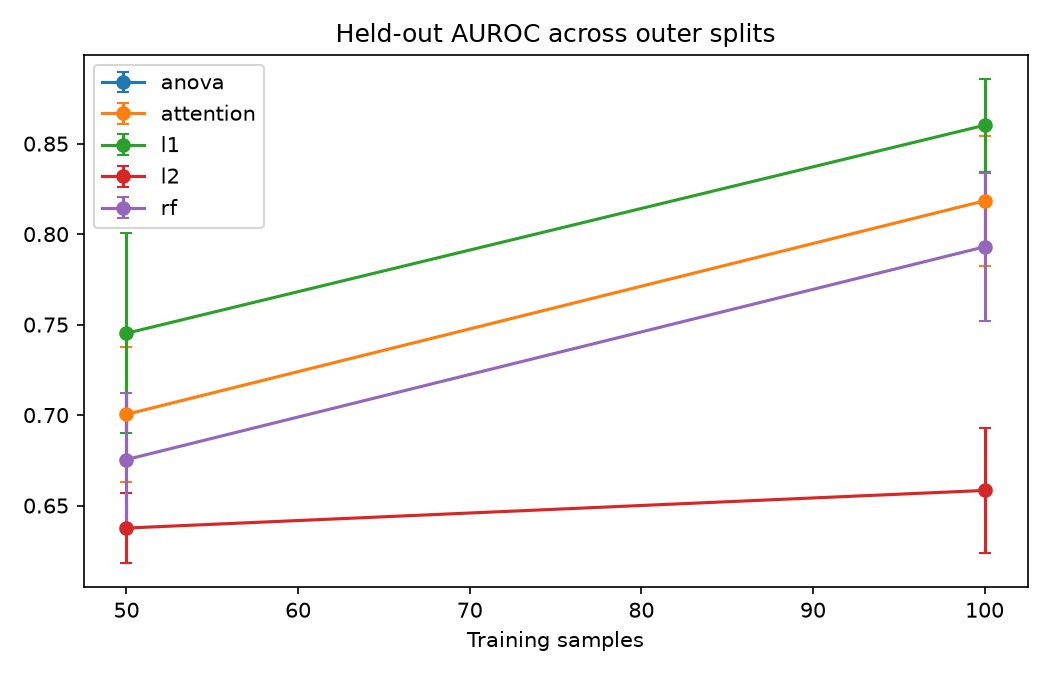


[aggregate_fixed_k_pairwise.csv]


,reference,baseline,n_train,k,n_outer_rows,delta_gene_jaccard_mean,delta_gene_jaccard_ci_low,delta_gene_jaccard_ci_high,delta_gene_jaccard_n,delta_module_jaccard_mean,...,baseline_gene_jaccard_ci_high,baseline_gene_jaccard_n,reference_auroc_mean,reference_auroc_ci_low,reference_auroc_ci_high,reference_auroc_n,baseline_auroc_mean,baseline_auroc_ci_low,baseline_auroc_ci_high,baseline_auroc_n
0,attention,l2,50,10,2,0.017699,-0.006433,0.041830,2,0.106765,...,0.132224,2,0.700415,0.663081,0.737749,2,0.637565,0.618242,0.656888,2
1,attention,l2,100,10,2,0.173175,0.147852,0.198497,2,0.335347,...,0.296008,2,0.818423,0.782628,0.854219,2,0.658360,0.623606,0.693114,2
2,attention,rf,50,10,2,0.045132,0.038012,0.052253,2,0.140619,...,0.121801,2,0.700415,0.663081,0.737749,2,0.675412,0.638847,0.711976,2
3,attention,rf,100,10,2,-0.044231,-0.051282,-0.037179,2,-0.135774,...,0.545788,2,0.818423,0.782628,0.854219,2,0.792989,0.752085,0.833894,2



[aggregate_gene_stability.png]


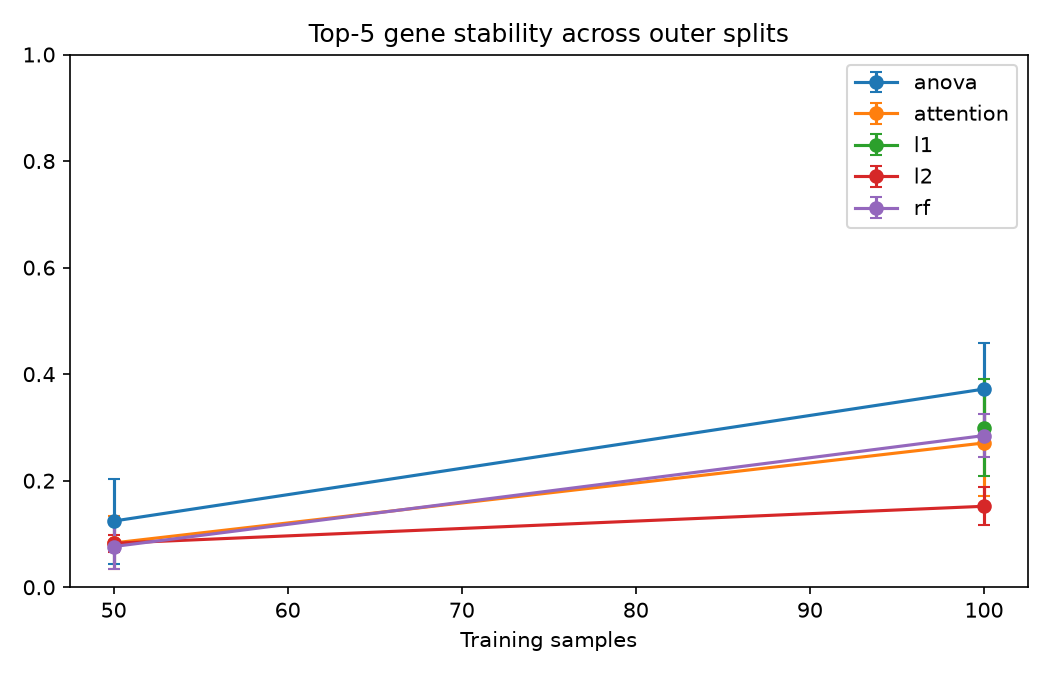


[aggregate_module_stability.png]


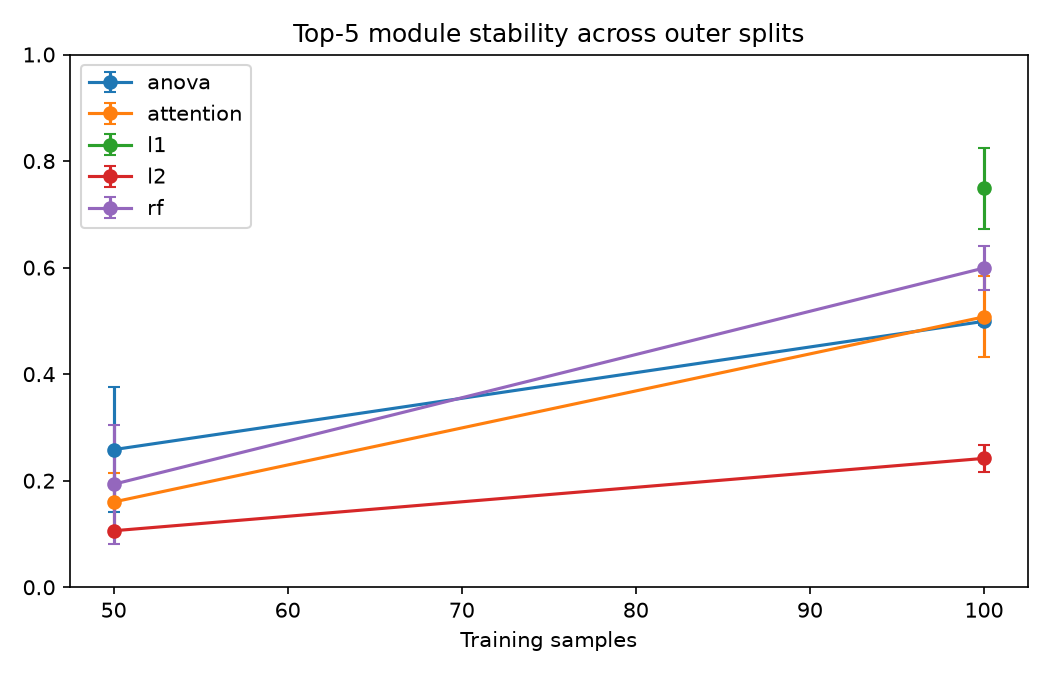


[aggregate_results.csv]


,method,experiment,n_train,k,n_outer_rows,auroc_mean_mean,auroc_mean_ci_low,auroc_mean_ci_high,auroc_mean_n,jaccard_gene_mean,...,pred_max_abs_ci_high,pred_max_abs_n,pred_jsd_mean,pred_jsd_ci_low,pred_jsd_ci_high,pred_jsd_n,pred_class_agreement_mean,pred_class_agreement_ci_low,pred_class_agreement_ci_high,pred_class_agreement_n
0,anova,subsample,50,5,2,NaN,NaN,NaN,0,0.124206,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
1,anova,subsample,50,10,2,NaN,NaN,NaN,0,0.195237,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
2,anova,subsample,50,20,2,NaN,NaN,NaN,0,0.207289,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
3,anova,subsample,50,50,2,NaN,NaN,NaN,0,0.185994,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
4,anova,subsample,100,5,2,NaN,NaN,NaN,0,0.372024,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
5,anova,subsample,100,10,2,NaN,NaN,NaN,0,0.551715,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
6,anova,subsample,100,20,2,NaN,NaN,NaN,0,0.643282,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
7,anova,subsample,100,50,2,NaN,NaN,NaN,0,0.293626,...,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0
8,attention,query,352,5,2,0.821057,0.787946,0.854167,2,1.000000,...,0.000000,2,0.000000,0.000000,0.000000,2,1.000000,1.000000,1.000000,2
9,attention,query,352,10,2,0.821057,0.787946,0.854167,2,1.000000,...,0.000000,2,0.000000,0.000000,0.000000,2,1.000000,1.000000,1.000000,2



[aggregate_tuned_performance.csv] could not be displayed as a DataFrame.

[common_matched_budget_diagnostic_outer.csv]


,experiment,n_train,method,matched_k,auroc_mean,jaccard_gene,jaccard_module,topk_valid_fraction,method_k_maximum,method_k_maxima,note,outer_id,outer_split_seed
0,seed,352,attention,20,0.863273,1.000000,1.000000,1.0,20,"{""attention"": 20, ""rf"": 20}",NaN,0,0
1,seed,352,rf,20,0.863109,1.000000,1.000000,1.0,20,"{""attention"": 20, ""rf"": 20}",NaN,0,0
2,subsample,50,anova,3,NaN,0.040000,0.133333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
3,subsample,50,attention,3,0.663081,0.020000,0.050000,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
4,subsample,50,l1,3,0.690058,0.050000,0.140000,1.0,3,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
5,subsample,50,l2,3,0.618242,0.020000,0.053333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
6,subsample,50,rf,3,0.638847,0.060000,0.128333,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 3, ""l2"": ...",NaN,0,0
7,subsample,100,anova,17,NaN,0.547595,0.583983,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0
8,subsample,100,attention,17,0.782628,0.472672,0.447782,1.0,20,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0
9,subsample,100,l1,17,0.834459,0.225771,0.250083,1.0,17,"{""anova"": 20, ""attention"": 20, ""l1"": 17, ""l2"":...",NaN,0,0



[fixed_k_pairwise_outer.csv]


...


[preregistered_decision.txt]
=== Pre-registered pilot decision (v4) ===
decision k=10; AUROC floor=0.75; 
gene-stability ceiling=0.50; pairwise margin=0.10
minimum outer splits with finite estimates=3
Insufficient outer-split evidence for a decision; do not interpret as a null result.

INCONCLUSIVE

[results_outer.csv]


,method,experiment,n_train,k,n_runs,rank_spearman_tie_aware,auroc_mean,auroc_sd,support_semantics,pred_prob_corr,...,known_median_rank,tie_boundary_fraction,support_shortfall_fraction,jaccard_index_tiebreak_diag,jaccard_random_tiebreak_diag,outer_id,outer_split_seed,query_invariance_pass,query_atol,query_rtol
0,rf,seed,352,5,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.369048,0.369048,0,0,NaN,NaN,NaN
1,rf,seed,352,10,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.674437,0.674437,0,0,NaN,NaN,NaN
2,rf,seed,352,20,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,1.000000,1.000000,0,0,NaN,NaN,NaN
3,rf,seed,352,50,3,0.413021,0.863109,0.010227,positive RF importance (diagnostic support),0.889141,...,NaN,0.0,0.0,0.389068,0.389068,0,0,NaN,NaN,NaN
4,attention,seed,352,5,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.619048,0.619048,0,0,NaN,NaN,NaN
5,attention,seed,352,10,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.767677,0.767677,0,0,NaN,NaN,NaN
6,attention,seed,352,20,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,1.000000,1.000000,0,0,NaN,NaN,NaN
7,attention,seed,352,50,3,0.781368,0.863273,0.018249,none,0.899328,...,NaN,0.0,0.0,0.563252,0.563252,0,0,NaN,NaN,NaN
8,attention,query,352,5,5,0.999884,0.854167,0.000000,none,1.000000,...,NaN,0.0,0.0,1.000000,1.000000,0,0,True,0.00001,0.0001
9,attention,query,352,10,5,0.999884,0.854167,0.000000,none,1.000000,...,NaN,0.0,0.0,1.000000,1.000000,0,0,True,0.00001,0.0001



[support_results_outer.csv]


,outer_id,outer_split_seed,experiment,n_train,method,support_semantics,support_size_mean,support_size_sd,support_size_median,support_size_min,support_size_max,support_jaccard_gene,support_jaccard_module,support_truth_precision,support_truth_recall,auroc_mean,auroc_sd
0,0,0,subsample,100,rf,positive RF importance (diagnostic support),499.2,0.748331,499.0,498,500,0.996800,1.000000,0.040064,1.00,0.752085,0.040151
1,0,0,subsample,100,l1,nonzero absolute L1 coefficient,24.2,4.261455,24.0,17,29,0.209535,0.223045,0.483818,0.57,0.834459,0.022917
2,0,0,subsample,50,rf,positive RF importance (diagnostic support),485.8,2.400000,484.0,484,490,0.944758,1.000000,0.040757,0.99,0.638847,0.031138
3,0,0,subsample,50,l1,nonzero absolute L1 coefficient,4.2,0.979796,4.0,3,6,0.052500,0.279405,0.650000,0.13,0.690058,0.074680
4,1,1009,subsample,100,rf,positive RF importance (diagnostic support),499.0,0.894427,499.0,498,500,0.996000,1.000000,0.040080,1.00,0.833894,0.020379
5,1,1009,subsample,100,l1,nonzero absolute L1 coefficient,22.6,2.727636,22.0,19,27,0.188425,0.244035,0.459917,0.51,0.885890,0.013091
6,1,1009,subsample,50,rf,positive RF importance (diagnostic support),482.8,2.925748,484.0,478,486,0.934681,1.000000,0.041427,1.00,0.711976,0.031962
7,1,1009,subsample,50,l1,nonzero absolute L1 coefficient,4.8,0.400000,5.0,4,5,0.111905,0.391429,0.750000,0.18,0.800362,0.041291



[tuned_performance_outer.csv] could not be displayed as a DataFrame.
=== Pre-registered pilot decision (v4) ===
decision k=10; AUROC floor=0.75; 
gene-stability ceiling=0.50; pairwise margin=0.10
minimum outer splits with finite estimates=3
Insufficient outer-split evidence for a decision; do not interpret as a null result.

INCONCLUSIVE


In [4]:
res = read_outputs(OUT)
print(res.get("decision", "No decision file"))

In [5]:
df = res["results_outer.csv"]
cols = [c for c in ["outer_id","method","experiment","n_train","k","jaccard_gene","jaccard_module","auroc_mean","pred_mad","pred_max_abs","query_invariance_pass"] if c in df.columns]
df[df["method"].eq("attention")][cols].round(4)

,outer_id,method,experiment,n_train,k,jaccard_gene,jaccard_module,auroc_mean,pred_mad,pred_max_abs,query_invariance_pass
4,0,attention,seed,352,5,0.6190,0.8333,0.8633,0.0758,0.4871,NaN
5,0,attention,seed,352,10,0.7677,1.0000,0.8633,0.0758,0.4871,NaN
6,0,attention,seed,352,20,1.0000,1.0000,0.8633,0.0758,0.4871,NaN
7,0,attention,seed,352,50,0.5633,0.4872,0.8633,0.0758,0.4871,NaN
8,0,attention,query,352,5,1.0000,1.0000,0.8542,0.0000,0.0000,True
9,0,attention,query,352,10,1.0000,1.0000,0.8542,0.0000,0.0000,True
10,0,attention,query,352,20,1.0000,1.0000,0.8542,0.0000,0.0000,True
11,0,attention,query,352,50,1.0000,1.0000,0.8542,0.0000,0.0000,True
28,0,attention,subsample,100,5,0.1706,0.4317,0.7826,0.1003,0.5988,NaN
29,0,attention,subsample,100,10,0.3286,0.5688,0.7826,0.1003,0.5988,NaN


For the query control, anchor predictions should stay numerically unchanged. Any attention change is interpreted only as a change in the aggregate readout.